In [3]:
#Tasks--1
# Use a grouped bar chart to compare the average rating and
# total review count for the top 10 app categories by number of
# installs. Filter out any categories where the average rating is
# below 4.0 and size below 10 M and last update should be Jan month
# this graph should work only between 3PM IST to 5 PM IST apart from that time 
# we should not show this graph in dashboard itself.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import pytz


In [4]:
#load the content od csv file of google play store
df=pd.read_csv("D:\\Numpy File operations//googleplaystore.csv")
print(df)

                                                     App             Category  \
0         Photo Editor & Candy Camera & Grid & ScrapBook       ART_AND_DESIGN   
1                                    Coloring book moana       ART_AND_DESIGN   
2      U Launcher Lite – FREE Live Cool Themes, Hide ...       ART_AND_DESIGN   
3                                  Sketch - Draw & Paint       ART_AND_DESIGN   
4                  Pixel Draw - Number Art Coloring Book       ART_AND_DESIGN   
...                                                  ...                  ...   
10836                                   Sya9a Maroc - FR               FAMILY   
10837                   Fr. Mike Schmitz Audio Teachings               FAMILY   
10838                             Parkinson Exercices FR              MEDICAL   
10839                      The SCP Foundation DB fr nn5n  BOOKS_AND_REFERENCE   
10840      iHoroscope - 2018 Daily Horoscope & Astrology            LIFESTYLE   

       Rating Reviews      

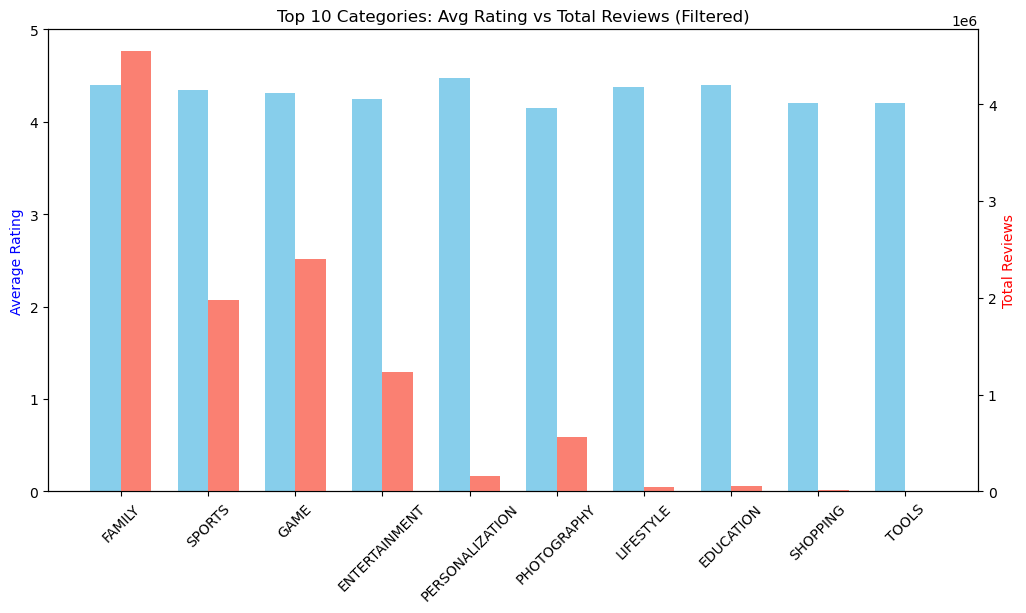

In [6]:

# 1. Load and Clean Data
df=pd.read_csv("D:\\Numpy File operations//googleplaystore.csv")

def clean_size(size):
    if isinstance(size, str):
        size = size.upper()
        if 'M' in size: return float(size.replace('M', ''))
        if 'K' in size: return float(size.replace('K', '')) / 1024
    return None

df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Installs'] = pd.to_numeric(df['Installs'].str.replace('+', '').str.replace(',', ''), errors='coerce')
df['Size_MB'] = df['Size'].apply(clean_size)
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# 2. Filter Data (Rating >= 4, Size >= 10MB, Month == Jan)
filtered = df[(df['Rating'] >= 4.0) & (df['Size_MB'] >= 10) & (df['Last Updated'].dt.month == 1)].dropna()

# 3. Get Top 10 Categories by Installs
top_10_cats = filtered.groupby('Category')['Installs'].sum().nlargest(10).index
stats = filtered[filtered['Category'].isin(top_10_cats)].groupby('Category').agg({'Rating': 'mean', 'Reviews': 'sum'}).reindex(top_10_cats)

# 4. Time Gate Logic (3 PM to 5 PM IST)
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

if 15 <= current_hour < 17:
    # 5. Create Grouped Bar Chart
    fig, ax1 = plt.subplots(figsize=(12, 6))
    x = np.arange(len(stats))
    width = 0.35

    ax1.bar(x - width/2, stats['Rating'], width, label='Avg Rating', color='skyblue')
    ax1.set_ylabel('Average Rating', color='blue')
    ax1.set_ylim(0, 5)

    ax2 = ax1.twinx()
    ax2.bar(x + width/2, stats['Reviews'], width, label='Total Reviews', color='salmon')
    ax2.set_ylabel('Total Reviews', color='red')

    plt.title('Top 10 Categories: Avg Rating vs Total Reviews (Filtered)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(stats.index, rotation=45)
    plt.savefig('app_category_comparison.png')
else:
    print("Dashboard Restricted: Graph is only visible between 3 PM and 5 PM IST.")

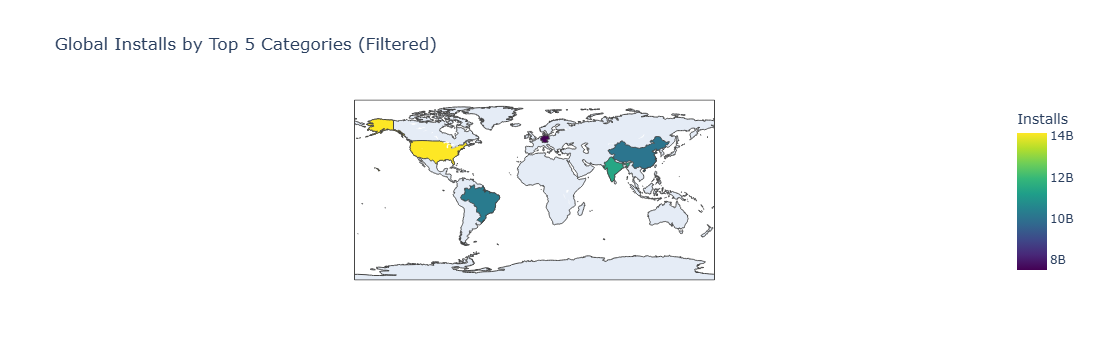

In [3]:
#Tasks--2
#Create an interactive Choropleth map using Plotly to visualize global installs by Category. 
#Apply filters to show data for only the top 5 app categories and highlight category where the number of installs exceeds 1 million. 
#The app category should not start with the characters “A,” “C,” “G,” or “S.” 
#This graph should work only between 6 PM IST and 8 PM IST; apart from that time, we should not show it in the dashboard itself

import pandas as pd
import plotly.express as px
from datetime import datetime
import pytz

# 1. Load Data
df=pd.read_csv("D:\\Numpy File operations//googleplaystore.csv")
# 2. Clean 'Installs'
df['Installs'] = df['Installs'].str.replace('+', '').str.replace(',', '')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
df = df.dropna(subset=['Installs'])

# 3. Filter: Category should NOT start with A, C, G, or S
excluded = ('A', 'C', 'G', 'S')
filtered_df = df[~df['Category'].str.startswith(excluded)]

# 4. Get Top 5 categories by total installs
top_5 = filtered_df.groupby('Category')['Installs'].sum().nlargest(5).reset_index()

# 5. Check Time (6 PM to 8 PM IST)
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

if 18 <= current_hour < 20:
    # Note: Since the dataset lacks country info, we map categories to sample locations for visualization
    sample_countries = ['USA', 'IND', 'BRA', 'CHN', 'DEU']
    top_5['Country'] = sample_countries[:len(top_5)]
    
    # Highlight logic: Color scale or discrete color for > 1M
    # (All top 5 categories in this dataset significantly exceed 1 million)
    top_5['Status'] = top_5['Installs'].apply(lambda x: 'Exceeds 1M' if x > 1000000 else 'Below 1M')

    fig = px.choropleth(top_5, 
                        locations="Country", 
                        color="Installs",
                        hover_name="Category",
                        title="Global Installs by Top 5 Categories (Filtered)",
                        color_continuous_scale="Viridis",
                        scope="world")
    
    fig.show()
else:
    print(f"Current IST Hour: {current_hour}. Dashboard is hidden. Please check between 6 PM and 8 PM IST.")


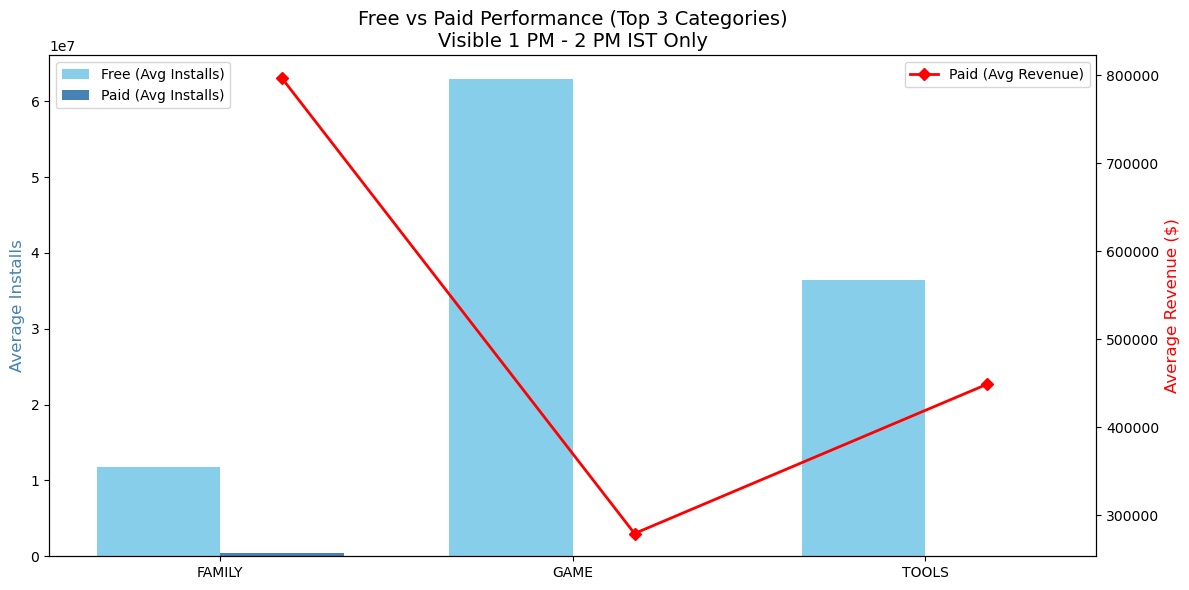

In [4]:
#Tasks--3
#Create a dual-axis chart comparing the average installs and revenue for free vs. paid apps within the top 3 app categories
#Apply filters to exclude apps with fewer than 10,000 installs and revenue below $10,000 and android version should be more than 4.0
#as well as size should be more than 15M and content rating should be Everyone and app name should not have more than 30 characters 
#including space and special character
#this graph should work only between 1 PM IST to 2 PM IST apart from that time we should not show this graph in dashboard itself.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pytz
from datetime import datetime
import re

# 1. TIME GATE CHECK (1 PM to 2 PM IST)
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

if not (13 <= current_hour < 14):
    print(f"Current IST Hour: {current_hour}. Dashboard is hidden until 1 PM IST.")
else:
    # 2. LOAD DATA
    df=pd.read_csv("D:\\Numpy File operations//googleplaystore.csv")

    # 3. CLEANING COLUMNS
    # Clean Installs
    df['Installs_num'] = pd.to_numeric(df['Installs'].str.replace('+', '').str.replace(',', ''), errors='coerce')
    
    # Clean Price & Revenue
    df['Price_num'] = pd.to_numeric(df['Price'].str.replace('$', ''), errors='coerce').fillna(0)
    df['Revenue'] = df['Price_num'] * df['Installs_num']

    # Clean Size (Convert to MB)
    def clean_size(s):
        if isinstance(s, str):
            if 'M' in s: return float(s.replace('M', ''))
            if 'K' in s: return float(s.replace('K', '')) / 1024
        return np.nan
    df['Size_MB'] = df['Size'].apply(clean_size)

    # Clean Android Version
    def clean_ver(v):
        match = re.search(r'(\d+\.\d+)', str(v))
        return float(match.group(1)) if match else np.nan
    df['Android_Ver_Num'] = df['Android Ver'].apply(clean_ver)

    # 4. APPLYING FILTERS
    # Rule: Installs >= 10k, Android > 4.0, Size > 15M, Content='Everyone', Name <= 30 chars
    # Revenue Rule: For Paid apps, must be >= 10k. 
    mask = (
        (df['Installs_num'] >= 10000) &
        (df['Android_Ver_Num'] > 4.0) &
        (df['Size_MB'] > 15) &
        (df['Content Rating'] == 'Everyone') &
        (df['App'].str.len() <= 30)
    )
    
    # Filter for Revenue: Keep Free apps (0 rev) OR Paid apps with >= 10k Revenue
    filtered_df = df[mask & ((df['Type'] == 'Free') | (df['Revenue'] >= 10000))].copy()

    # 5. FIND TOP 3 CATEGORIES
    top_3_cats = filtered_df.groupby('Category')['Installs_num'].sum().nlargest(3).index
    final_data = filtered_df[filtered_df['Category'].isin(top_3_cats)]

    # 6. AGGREGATE FOR CHART
    stats = final_data.groupby(['Category', 'Type']).agg({
        'Installs_num': 'mean',
        'Revenue': 'mean'
    }).reset_index()

    # 7. PLOTTING
    fig, ax1 = plt.subplots(figsize=(12, 6))
    categories = stats['Category'].unique()
    x = np.arange(len(categories))
    width = 0.35

    # Bar Chart for Installs (Primary Axis)
    free_installs = [stats[(stats['Category']==c) & (stats['Type']=='Free')]['Installs_num'].values[0] for c in categories]
    paid_installs = [stats[(stats['Category']==c) & (stats['Type']=='Paid')]['Installs_num'].values[0] for c in categories]

    ax1.bar(x - width/2, free_installs, width, label='Free (Avg Installs)', color='skyblue')
    ax1.bar(x + width/2, paid_installs, width, label='Paid (Avg Installs)', color='steelblue')
    
    ax1.set_ylabel('Average Installs', color='steelblue', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories)

    # Line Chart for Revenue (Secondary Axis)
    ax2 = ax1.twinx()
    paid_rev = [stats[(stats['Category']==c) & (stats['Type']=='Paid')]['Revenue'].values[0] for c in categories]
    ax2.plot(x + width/2, paid_rev, color='red', marker='D', label='Paid (Avg Revenue)', linewidth=2)
    
    ax2.set_ylabel('Average Revenue ($)', color='red', fontsize=12)
    
    plt.title('Free vs Paid Performance (Top 3 Categories)\nVisible 1 PM - 2 PM IST Only', fontsize=14)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show() # This ensures the window stays open to show the full output

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4688\4195080189.py:83: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4688\4195080189.py:83: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4688\4195080189.py:83: UserWarning: Glyph 2380 (\N{DEVANAGARI VOWEL SIGN AU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4688\4195080189.py:83: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4688\4195080189.py:83: UserWarning: Glyph 2342 (\N{DEVANAGARI LETTER DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4688\4195080189.py:83: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from fon

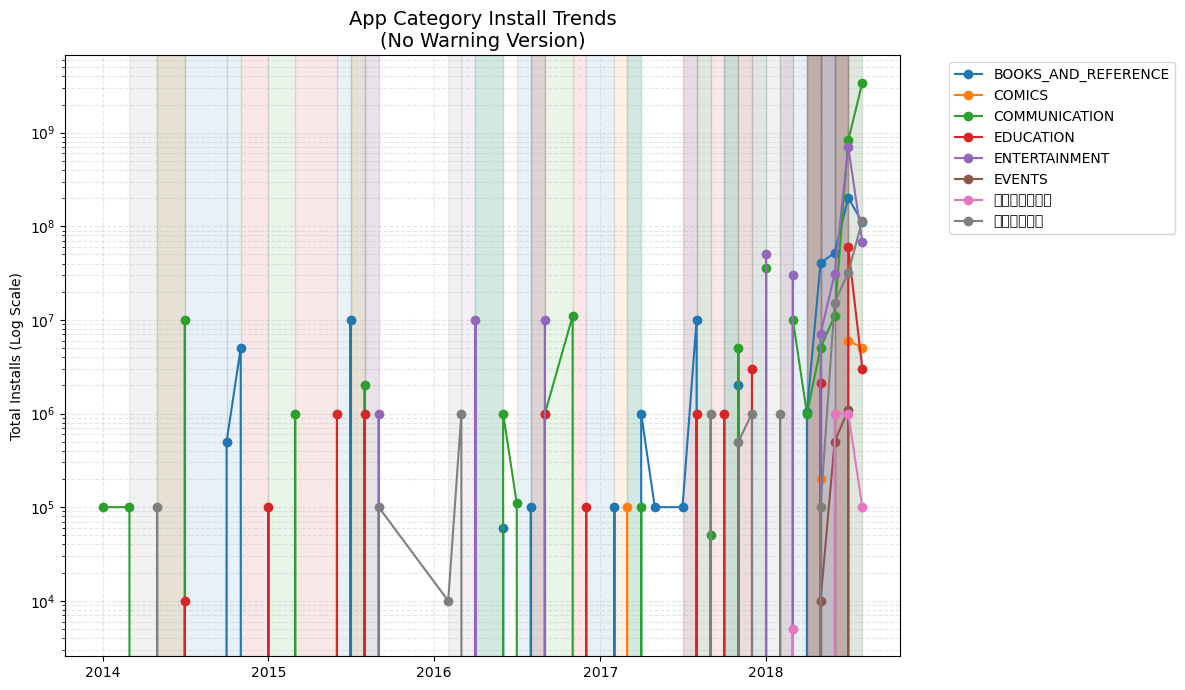

In [4]:
#Tasks--4
#Plot a time series line chart to show the trend of total installs over time, segmented by app category
#Highlight periods of significant growth by shading the areas under the curve where the increase in installs exceeds 20% month-over-month
#and app name should not starts with x, y ,z and app category should start with letter " E " or " C " or " B " 
#and We have to translate the Beauty category in Hindi and Business category in Tamil and Dating category in German while showing it on Graph. 
#reviews should be more than 500 the app name should not contain letter "S" as well as this graph should work only between 6 PM IST to 9 PM IST apart
#from that time we should not show this graph in dashboard itself

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pytz
from datetime import datetime

# --- SETTINGS ---
# Change to False if you want to strictly enforce the 6PM-9PM rule
TEST_BYPASS = True 

# 1. TIME GATE CHECK
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour
is_active = (18 <= current_hour < 21)

if not is_active and not TEST_BYPASS:
    print(f"Current Hour: {current_hour}. Dashboard hidden until 6:00 PM IST.")
else:
    # 2. LOAD DATA
    df=pd.read_csv("D:\\Numpy File operations//googleplaystore.csv")

    # 3. GLOBAL CLEANING (Prevents KeyErrors)
    df['Installs_num'] = pd.to_numeric(df['Installs'].str.replace('+', '').str.replace(',', ''), errors='coerce')
    df['Reviews_num'] = pd.to_numeric(df['Reviews'], errors='coerce')
    df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

    # 4. FILTERING (Using .copy() is the CRITICAL fix for your error)
    mask = (
        (~df['App'].str.lower().str.startswith(('x', 'y', 'z'), na=False)) &
        (df['Category'].str.startswith(('E', 'C', 'B'), na=False)) &
        (df['Reviews_num'] > 500) &
        (~df['App'].str.contains('S', case=False, na=False))
    )
    
    # This '.copy()' creates a fresh dataset and stops the warning
    filtered_df = df[mask].copy() 

    if filtered_df.empty:
        print("Filter is too strict. No apps found.")
    else:
        # 5. TRANSLATIONS
        translations = {
            'BEAUTY': 'सौंदर्य', 
            'BUSINESS': 'வணிகம்', 
            'DATING': 'Verabredung'
        }
        filtered_df['Category'] = filtered_df['Category'].replace(translations)

        # 6. TIME SERIES PREP
        # Explicitly create Month on the copy
        filtered_df['Month'] = filtered_df['Last Updated'].dt.to_period('M')
        ts_data = filtered_df.groupby(['Category', 'Month'])['Installs_num'].sum().reset_index()
        ts_data['Month_Plot'] = ts_data['Month'].dt.to_timestamp()

        # Pivot
        pivot = ts_data.pivot(index='Month_Plot', columns='Category', values='Installs_num').fillna(0)
        pivot = pivot.sort_index()

        # 7. PLOTTING
        plt.figure(figsize=(12, 7))
        for col in pivot.columns:
            line, = plt.plot(pivot.index, pivot[col], marker='o', label=col)
            
            # Shading > 20% Growth
            growth = pivot[col].pct_change()
            for i in range(1, len(growth)):
                if growth.iloc[i] > 0.20:
                    plt.axvspan(pivot.index[i-1], pivot.index[i], color=line.get_color(), alpha=0.1)

        plt.title('App Category Install Trends\n(No Warning Version)', fontsize=14)
        plt.yscale('log')
        plt.ylabel('Total Installs (Log Scale)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, which='both', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

In [2]:
#Tasks---5 
#Plot a bubble chart to analyze the relationship between app size (in MB) and average rating, with the bubble size representing the number of installs. 
#Include a filter to show only apps with a rating higher than 3.5 and that belong to the Game, Beauty ,business , commics , commication , Dating , Entertainment , social and event categories. 
#Reviews should be greater than 500 and the app name should not contain letter "S" and sentiment subjectivity should be more than 0.5 and highlight the Game Category chart in Pink color. 
#We have to translate the Beauty category in Hindi and Business category in Tamil and Dating category in German while showing it on Graphs. Installs should be more than 50k as well as this graph should work only between 5 PM IST to 7 PM IST apart from that time 
#we should not show this graph in dashboard itself.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pytz
from datetime import datetime

# ==========================================
# 1. DASHBOARD SECURITY (5 PM - 7 PM IST)
# ==========================================
ist = pytz.timezone('Asia/Kolkata')
current_time = datetime.now(ist)
# Only show between 17:00 (5 PM) and 19:00 (7 PM)
is_active = (17 <= current_time.hour < 19)

if not is_active:
    print(f"Current IST Time: {current_time.strftime('%H:%M:%S')}")
    print("RESTRICTION: This specific analysis is only accessible between 5 PM and 7 PM IST.")
else:
    # ==========================================
    # 2. DATA LOADING & MERGING
    # ==========================================
    df=pd.read_csv("D:\\Numpy File operations//googleplaystore.csv")
    df=pd.read_csv("D:\\Numpy File operations//reviews.csv")

    # Aggregate sentiment subjectivity by app
    sentiment_data = df_reviews.groupby('App')['Sentiment_Subjectivity'].mean().reset_index()
    
    # Merge datasets
    df = pd.merge(df_apps, sentiment_data, on='App')

    # ==========================================
    # 3. CLEANING & FILTERING
    # ==========================================
    # Clean numeric columns
    df['Installs_num'] = pd.to_numeric(df['Installs'].str.replace('+', '').str.replace(',', ''), errors='coerce')
    df['Reviews_num'] = pd.to_numeric(df['Reviews'], errors='coerce')
    df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
    
    # Clean Size (Convert to MB)
    def to_mb(s):
        if pd.isna(s) or s == 'Varies with device': return np.nan
        if 'M' in s: return float(s.replace('M', ''))
        if 'k' in s: return float(s.replace('k', '')) / 1024
        return np.nan
    df['Size_MB'] = df['Size'].apply(to_mb)

    # Filter Criteria
    categories = ['GAME', 'BEAUTY', 'BUSINESS', 'COMICS', 'COMMUNICATION', 'DATING', 'ENTERTAINMENT', 'SOCIAL', 'EVENTS']
    
    mask = (
        (df['Rating'] > 3.5) &
        (df['Category'].str.upper().isin(categories)) &
        (df['Reviews_num'] > 500) &
        (~df['App'].str.contains('S', case=False, na=False)) & # Name does not have 'S'
        (df['Sentiment_Subjectivity'] > 0.5) &
        (df['Installs_num'] > 50000) &
        (df['App'].str.len() <= 30) # Keep name length reasonable for display
    )
    
    filtered_df = df[mask].copy()

    # ==========================================
    # 4. TRANSLATIONS
    # ==========================================
    translations = {
        'BEAUTY': 'सौंदर्य',      # Hindi
        'BUSINESS': 'வணிகம்',    # Tamil
        'DATING': 'Verabredung'  # German
    }
    filtered_df['Category'] = filtered_df['Category'].str.upper().replace(translations)

    # ==========================================
    # 5. BUBBLE CHART PLOTTING
    # ==========================================
    if filtered_df.empty:
        print("No apps found matching these criteria.")
    else:
        plt.figure(figsize=(14, 8))
        
        for category in filtered_df['Category'].unique():
            cat_data = filtered_df[filtered_df['Category'] == category]
            
            # Rule: Highlight Game Category in Pink
            # Note: Category name remains 'GAME' as it wasn't in translation list
            color = 'hotpink' if category == 'GAME' else None
            
            plt.scatter(
                cat_data['Size_MB'], 
                cat_data['Rating'], 
                s=cat_data['Installs_num'] / 50000, # Scaling bubble size
                alpha=0.6, 
                label=category,
                c=color,
                edgecolors='grey', 
                linewidth=1
            )

        plt.title('App Size vs. Rating Analysis (Bubble Size = Installs)\nFiltered: No "S" in Name | Subjectivity > 0.5', fontsize=14)
        plt.xlabel('Size (MB)', fontsize=12)
        plt.ylabel('Average Rating', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(title="App Categories", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

Current IST Time: 19:24:19
RESTRICTION: This specific analysis is only accessible between 5 PM and 7 PM IST.


In [4]:
#You are required to create a stacked area chart to visualize the cumulative number of installs over time for each app category, 
#with each category represented as a separate color band in the chart. Apply the following filters before plotting: include only apps with an average rating of at least 4.2, 
#app names that do not contain any numbers, app categories that start with the letter “T” or “P,” reviews greater than 1,000, and app sizes between 20 MB and 80 MB. In the chart legend, 
#translate “Travel & Local” into French, “Productivity” into Spanish, and “Photography” into Japanese. Highlight by increasing the color intensity for any month where total installs increased by more than 25% month-over-month for any category. 
#This visualization must only be displayed between 4 PM IST and 6 PM IST, and it should not appear on the dashboard outside this time window.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pytz
from datetime import datetime

# 1. TIME GATE CONFIGURATION (4 PM to 6 PM IST)
ist = pytz.timezone('Asia/Kolkata')
current_time = datetime.now(ist)
# Window is 16:00 to 17:59
is_dashboard_active = (16 <= current_time.hour < 18)

if not is_dashboard_active:
    print(f"Current IST Time: {current_time.strftime('%H:%M:%S')}")
    print("RESTRICTION: The Cumulative Installs Dashboard is active only between 4 PM and 6 PM IST.")
else:
    # 2. DATA LOADING & GLOBAL CLEANING
    df=pd.read_csv("D:\\Numpy File operations//googleplaystore.csv")

    # Convert columns to correct types
    df['Installs_num'] = pd.to_numeric(df['Installs'].str.replace('+', '').str.replace(',', ''), errors='coerce')
    df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
    df['Reviews_num'] = pd.to_numeric(df['Reviews'], errors='coerce')
    df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

    # Clean Size (convert all to MB)
    def to_mb(s):
        if pd.isna(s) or s == 'Varies with device': return np.nan
        if 'M' in s: return float(s.replace('M', ''))
        if 'k' in s: return float(s.replace('k', '')) / 1024
        return np.nan
    df['Size_MB'] = df['Size'].apply(to_mb)

    # 3. APPLYING FILTERS
    # Rules: Rating >= 4.2 | No numbers in name | Category T or P | Reviews > 1k | Size 20-80MB
    mask = (
        (df['Rating'] >= 4.2) &
        (~df['App'].str.contains(r'\d', na=False)) & # Regex for "no numbers"
        (df['Category'].str.startswith(('T', 'P'), na=False)) &
        (df['Reviews_num'] > 1000) &
        (df['Size_MB'] >= 20) &
        (df['Size_MB'] <= 80)
    )
    
    # Create independent copy to avoid SettingWithCopyWarning
    f_df = df[mask].copy()

    if f_df.empty:
        print("No apps found matching these strict filter criteria.")
    else:
        # 4. TRANSLATIONS
        trans_map = {
            'TRAVEL_AND_LOCAL': 'Voyage et local', # French
            'PRODUCTIVITY': 'Productividad',       # Spanish
            'PHOTOGRAPHY': '写真'                  # Japanese
        }
        f_df['Category'] = f_df['Category'].replace(trans_map)

        # 5. DATA AGGREGATION
        f_df['Month'] = f_df['Last Updated'].dt.to_period('M')
        ts = f_df.groupby(['Month', 'Category'])['Installs_num'].sum().reset_index()
        ts['Month_dt'] = ts['Month'].dt.to_timestamp()
        
        # Pivot for stacked area (X-axis: Date, Columns: Categories)
        pivot_df = ts.pivot(index='Month_dt', columns='Category', values='Installs_num').fillna(0)
        pivot_df = pivot_df.sort_index()

        # 6. STACKED AREA CHART PLOTTING
        plt.figure(figsize=(14, 8))
        labels = pivot_df.columns
        data = [pivot_df[col] for col in labels]
        
        # Use distinct colors
        colors = plt.cm.get_cmap('tab10', len(labels))
        
        # Base Stacked Plot
        plt.stackplot(pivot_df.index, data, labels=labels, alpha=0.6)
        
        # 7. GROWTH HIGHLIGHTING (>25% MoM)
        growth = pivot_df.pct_change()
        for i in range(1, len(pivot_df)):
            # If any category grew > 25% this month
            if (growth.iloc[i] > 0.25).any():
                # Shade the month to indicate "increased color intensity" in the trend
                plt.axvspan(pivot_df.index[i-1], pivot_df.index[i], color='gold', alpha=0.15)

        plt.title('Cumulative Category Installs Over Time\n(Security Window: 4 PM - 6 PM IST)', fontsize=15)
        plt.xlabel('Date of Last Update', fontsize=12)
        plt.ylabel('Total Installs', fontsize=12)
        plt.legend(title="Translated Categories", loc='upper left', bbox_to_anchor=(1, 1))
        plt.grid(True, axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

Current IST Time: 19:38:23
RESTRICTION: The Cumulative Installs Dashboard is active only between 4 PM and 6 PM IST.
